# Week 7 Lab: Evaluation, decision thresholds, calibration and imbalanced data


AIE683 Machine Learning, Hacettepe University.

**The case.** In breast-cancer screening, only a small fraction of mammograms show anything suspicious.
A model that labels every image "normal" is more than 97% accurate and completely useless. A missed finding
(false negative) costs far more than an extra review by a radiologist (false positive). This lab is about
measuring models in a way that reflects that reality, and about turning scores into decisions.

Data:
* **Mammography** (OpenML 310): 11,183 regions of interest, 6 features, 2.3% positive (micro-calcifications).
* **Adult census income** (OpenML 1590): 48,842 people, predict income > 50K; used for calibration and MLflow.

Sections
1. Metrics beyond accuracy
2. **Try it 1:** predict which model wins, then measure
3. Decision thresholds (`FixedThresholdClassifier`, `TunedThresholdClassifierCV`)
4. **Try it 2:** set the threshold for the clinic (cost competition)
5. Imbalanced data: class weights and resampling
6. **Try it 3:** spot the leak
7. Calibration (`CalibrationDisplay`, `CalibratedClassifierCV`)
8. Logging competing models to MLflow

Exercise cells are marked **TODO**. They run as provided; replace the placeholders with your code.

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "2"   # keep the lab light on shared machines
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score, average_precision_score,
                             roc_auc_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay)

SEED = 0
np.random.seed(SEED)
np.set_printoptions(precision=3, suppress=True)
pd.set_option("display.precision", 3)

## 1. Metrics beyond accuracy

In [2]:
mammo = fetch_openml("mammography", version=1, as_frame=True)
X = mammo.data.to_numpy()
y = (mammo.target == "1").to_numpy()      # boolean target: True is the positive (minority) class
print(X.shape, "positives:", y.sum(), f"({y.mean():.1%})")

# hold out a test set that we only touch at the end of each section
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=SEED)

(11183, 6) positives: 260 (2.3%)


In [3]:
# a "model" that always predicts the majority class
print("accuracy of always-negative:", accuracy_score(y_test, np.zeros_like(y_test)))

lr = make_pipeline(StandardScaler(), LogisticRegression()).fit(X_train, y_train)
rf = RandomForestClassifier(n_jobs=-1, random_state=SEED).fit(X_train, y_train)
print(classification_report(y_test, rf.predict(X_test)))

accuracy of always-negative: 0.9767525035765379
              precision    recall  f1-score   support

       False       0.99      1.00      0.99      2731
        True       0.90      0.58      0.71        65

    accuracy                           0.99      2796
   macro avg       0.95      0.79      0.85      2796
weighted avg       0.99      0.99      0.99      2796



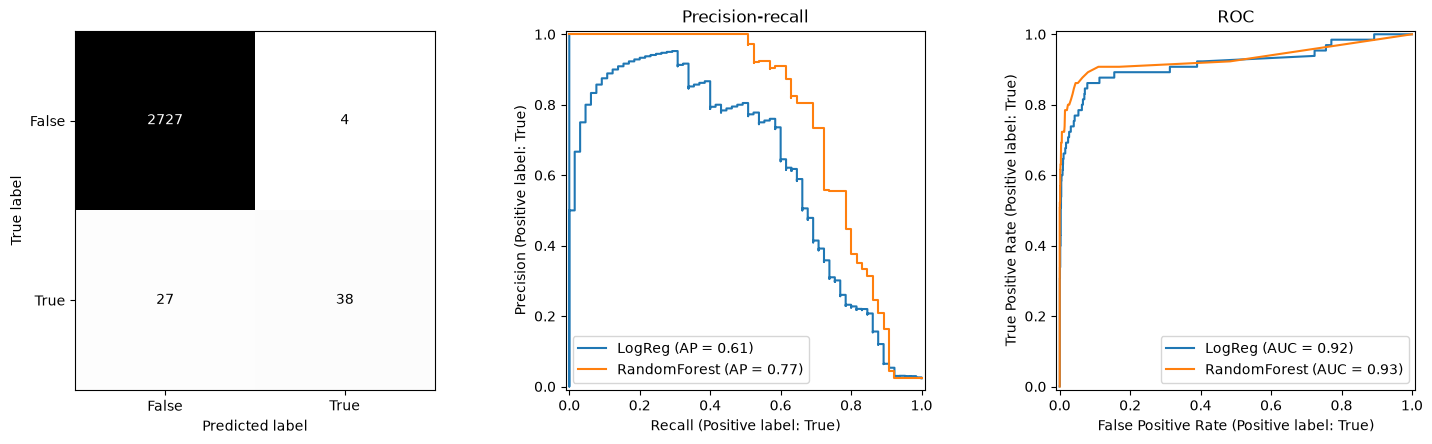

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, ax=axes[0], colorbar=False, cmap="gray_r")
for name, m in [("LogReg", lr), ("RandomForest", rf)]:
    PrecisionRecallDisplay.from_estimator(m, X_test, y_test, name=name, ax=axes[1])
    RocCurveDisplay.from_estimator(m, X_test, y_test, name=name, ax=axes[2])
axes[1].set_title("Precision-recall")
axes[2].set_title("ROC")
plt.tight_layout()

In [5]:
def metric_table(models, X, y):
    """Threshold-based and ranking metrics for a dict of fitted binary classifiers."""
    rows = {}
    for name, m in models.items():
        pred = m.predict(X)
        score = m.predict_proba(X)[:, 1]
        rows[name] = {"accuracy": accuracy_score(y, pred),
                      "balanced_acc": balanced_accuracy_score(y, pred),
                      "f1": f1_score(y, pred),
                      "avg_precision": average_precision_score(y, score),
                      "roc_auc": roc_auc_score(y, score)}
    return pd.DataFrame(rows).T

metric_table({"LogReg": lr, "RandomForest": rf}, X_test, y_test)

,accuracy,balanced_acc,f1,avg_precision,roc_auc
LogReg,0.985,0.737,0.596,0.614,0.917
RandomForest,0.989,0.792,0.710,0.767,0.930


## 2. Try it 1: predict which model wins, then measure (10 min)

We compare three models on the mammography data with 5-fold cross-validation on the training set:

* `LogisticRegression` (scaled)
* `RandomForestClassifier`
* `RandomForestClassifier(class_weight="balanced")`

**Before running anything**, write down in the cell below which model you expect to win on
(a) accuracy, (b) balanced accuracy, (c) average precision and (d) ROC AUC. Then complete the TODO,
run it and compare with your prediction. Which metric changes the ranking the most, and why?

In [6]:
my_predictions = {"accuracy": "?", "balanced_accuracy": "?", "average_precision": "?", "roc_auc": "?"}

In [7]:
candidates = {
    "logreg": make_pipeline(StandardScaler(), LogisticRegression()),
    "rf": RandomForestClassifier(n_jobs=-1, random_state=SEED),
    "rf_balanced": RandomForestClassifier(class_weight="balanced", n_jobs=-1, random_state=SEED),
}
scoring = ["accuracy"]   # TODO: add "balanced_accuracy", "average_precision", "roc_auc"

results = {}
for name, model in candidates.items():
    cv = cross_validate(model, X_train, y_train, cv=5, scoring=scoring)
    results[name] = {s: cv[f"test_{s}"].mean() for s in scoring}
pd.DataFrame(results).T

,accuracy
logreg,0.983
rf,0.986
rf_balanced,0.985


## 3. Decision thresholds

`predict` cuts `predict_proba` at 0.5. That cut-off is a decision, not a property of the model.
`FixedThresholdClassifier` sets it by hand; `TunedThresholdClassifierCV` picks it by cross-validation
to maximise any scorer, including a business cost.

In [8]:
from sklearn.model_selection import FixedThresholdClassifier, TunedThresholdClassifierCV
from sklearn.metrics import make_scorer

rf_03 = FixedThresholdClassifier(RandomForestClassifier(n_jobs=-1, random_state=SEED), threshold=0.3)
rf_03.fit(X_train, y_train)
print(classification_report(y_test, rf_03.predict(X_test)))

              precision    recall  f1-score   support

       False       0.99      0.99      0.99      2731
        True       0.74      0.69      0.71        65

    accuracy                           0.99      2796
   macro avg       0.87      0.84      0.85      2796
weighted avg       0.99      0.99      0.99      2796



tuned threshold: 0.110
test cost, default threshold: 544
test cost, tuned threshold:   328


Text(0, 0.5, 'mean CV cost per fold')

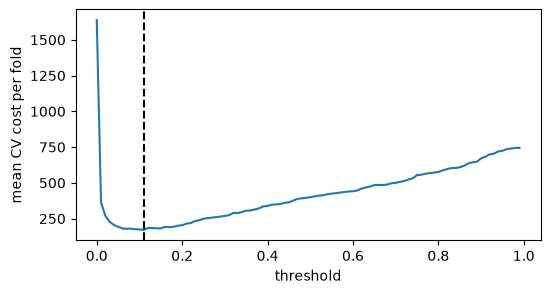

In [9]:
def total_cost(y_true, y_pred, cost_fp=1, cost_fn=20):
    """Total cost of a set of decisions; correct decisions are free."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[False, True]).ravel()
    return cost_fp * fp + cost_fn * fn

# scorers must be "higher is better", so we use the negative cost
cost_scorer = make_scorer(total_cost, greater_is_better=False)

tuned = TunedThresholdClassifierCV(RandomForestClassifier(n_jobs=-1, random_state=SEED),
                                   scoring=cost_scorer, cv=5, store_cv_results=True, random_state=SEED)
tuned.fit(X_train, y_train)
print(f"tuned threshold: {tuned.best_threshold_:.3f}")
print("test cost, default threshold:", total_cost(y_test, rf.predict(X_test)))
print("test cost, tuned threshold:  ", total_cost(y_test, tuned.predict(X_test)))

plt.figure(figsize=(6, 3))
plt.plot(tuned.cv_results_["thresholds"], -tuned.cv_results_["scores"])
plt.axvline(tuned.best_threshold_, ls="--", c="k")
plt.xlabel("threshold")
plt.ylabel("mean CV cost per fold")

## 4. Try it 2: set the threshold for the clinic (15 min, small competition)

The screening clinic tells you: a missed finding costs **50**, a false alarm costs **1**.

1. Build any classifier you like (a pipeline is fine) and choose its threshold **using only the training data**
   (`TunedThresholdClassifierCV`, or your own cross-validation).
2. Report the cost on the held-out test set with `total_cost(y_test, y_pred, cost_fp=1, cost_fn=50)`.
3. Post your test cost; lowest cost wins. Anyone who tuned on the test set is disqualified.

Question for discussion: how does the optimal threshold move when the cost ratio changes from 20 to 50, and why?

In [10]:
COST_FP, COST_FN = 1, 50

my_model = RandomForestClassifier(n_jobs=-1, random_state=SEED)   # TODO: choose your model
# TODO: wrap my_model in TunedThresholdClassifierCV with a scorer built from
#       total_cost(..., cost_fp=COST_FP, cost_fn=COST_FN), then fit on the training data
my_model.fit(X_train, y_train)

my_test_cost = total_cost(y_test, my_model.predict(X_test), cost_fp=COST_FP, cost_fn=COST_FN)
print("my test cost:", my_test_cost)

my test cost: 1354


## 5. Imbalanced data: class weights and resampling

`imbalanced-learn` provides samplers (`fit_resample`) and a `Pipeline` that applies them **only during `fit`**,
so validation and test folds keep the original class distribution.

In [11]:
from imblearn.pipeline import make_pipeline as make_imb_pipeline
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from imblearn.ensemble import BalancedRandomForestClassifier

def cv_scores(model):
    cv = cross_validate(model, X_train, y_train, cv=5, scoring=["roc_auc", "average_precision"], n_jobs=-1)
    return {"roc_auc": cv["test_roc_auc"].mean(), "avg_precision": cv["test_average_precision"].mean()}

variants = {
    "logreg": make_pipeline(StandardScaler(), LogisticRegression()),
    "logreg balanced weights": make_pipeline(StandardScaler(), LogisticRegression(class_weight="balanced")),
    "undersample + RF": make_imb_pipeline(RandomUnderSampler(random_state=SEED),
                                          RandomForestClassifier(random_state=SEED)),
    "SMOTE + RF": make_imb_pipeline(SMOTE(random_state=SEED), RandomForestClassifier(random_state=SEED)),
    "BalancedRandomForest": BalancedRandomForestClassifier(random_state=SEED),
}
pd.DataFrame({name: cv_scores(m) for name, m in variants.items()}).T

,roc_auc,avg_precision
logreg,0.920,0.625
logreg balanced weights,0.917,0.565
undersample + RF,0.949,0.572
SMOTE + RF,0.948,0.688
BalancedRandomForest,0.953,0.643


## 6. Try it 3: spot the leak (10 min)

A colleague reports that SMOTE gives a large jump in average precision. Their code is below.
Run it, then find what is wrong, fix it in the TODO cell, and compare the two numbers.
Which number would you put in a paper?

In [12]:
# colleague's code (do not edit)
X_res, y_res = SMOTE(random_state=SEED).fit_resample(X_train, y_train)
leaky = cross_validate(RandomForestClassifier(n_jobs=-1, random_state=SEED), X_res, y_res, cv=5,
                       scoring="average_precision")
print(f"reported average precision: {leaky['test_score'].mean():.3f}")

reported average precision: 0.989


In [13]:
# TODO: evaluate SMOTE + RandomForest so that resampling happens only inside each training fold.
fixed_ap = np.nan
print(f"honest average precision: {fixed_ap:.3f}")

honest average precision: nan


## 7. Calibration on the Adult census data

Here the question is not only *who* earns more than 50K, but *how confident* the model should be.
We compare reliability diagrams and fix a miscalibrated model with `CalibratedClassifierCV`.

In [14]:
from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import brier_score_loss, log_loss

adult = fetch_openml("adult", version=2, as_frame=True)
Xa = adult.data.drop(columns=["fnlwgt", "education"])   # sampling weight and a duplicate of education-num
ya = (adult.target == ">50K").astype(int).to_numpy()
Xa_train, Xa_test, ya_train, ya_test = train_test_split(Xa, ya, train_size=20_000, stratify=ya,
                                                        random_state=SEED)
cat = make_column_selector(dtype_include="category")
num = make_column_selector(dtype_exclude="category")
onehot = make_column_transformer((OneHotEncoder(handle_unknown="ignore", min_frequency=20), cat),
                                 (StandardScaler(), num))
ordinal = make_column_transformer((OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1,
                                                  encoded_missing_value=-1), cat),
                                  ("passthrough", num))
print(Xa_train.shape, f"positive rate {ya_train.mean():.2f}")

(20000, 12) positive rate 0.24


Text(0.5, 1.0, 'Reliability diagrams on the Adult test set')

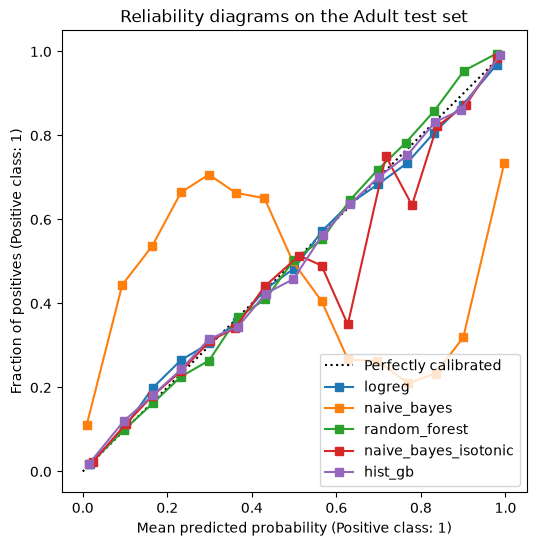

In [15]:
adult_models = {
    "logreg": make_pipeline(onehot, LogisticRegression(max_iter=1000)),
    "naive_bayes": make_pipeline(ordinal, GaussianNB()),
    "random_forest": make_pipeline(ordinal, RandomForestClassifier(min_samples_leaf=3, n_jobs=-1,
                                                                   random_state=SEED)),
    "naive_bayes_isotonic": CalibratedClassifierCV(make_pipeline(ordinal, GaussianNB()),
                                                   method="isotonic", cv=5, ensemble=True),
    "hist_gb": HistGradientBoostingClassifier(categorical_features="from_dtype", random_state=SEED),
}
for m in adult_models.values():
    m.fit(Xa_train, ya_train)

fig, ax = plt.subplots(figsize=(6, 6))
for name, m in adult_models.items():
    CalibrationDisplay.from_estimator(m, Xa_test, ya_test, n_bins=15, name=name, ax=ax)
ax.set_title("Reliability diagrams on the Adult test set")

Note: calibration changes probabilities, not (much) the ranking. Compare ROC AUC with Brier score below:
the isotonic step fixes Naive Bayes' Brier score while its ROC AUC barely moves.

## 8. Logging competing models to MLflow

For each model we log its type, test metrics and its reliability diagram as an artifact, then query the runs back.
Start the UI from the repository root with `uv run mlflow ui` to browse and compare them.

In [16]:
import mlflow

mlflow.set_experiment("week07-evaluation")
print("tracking URI:", mlflow.get_tracking_uri())

import time
batch = time.strftime("%Y%m%d-%H%M%S")   # tag to find this notebook run's models again
rows = []
for name, model in adult_models.items():
    with mlflow.start_run(run_name=name, tags={"batch": batch}):
        p = model.predict_proba(Xa_test)[:, 1]
        metrics = {"brier": brier_score_loss(ya_test, p),
                   "log_loss": log_loss(ya_test, np.clip(p, 1e-6, 1 - 1e-6)),
                   "roc_auc": roc_auc_score(ya_test, p),
                   "average_precision": average_precision_score(ya_test, p),
                   "accuracy": accuracy_score(ya_test, p > .5)}
        mlflow.log_param("estimator", type(model).__name__)
        mlflow.log_param("n_train", len(ya_train))
        mlflow.log_metrics(metrics)
        fig, ax = plt.subplots(figsize=(4, 4))
        CalibrationDisplay.from_predictions(ya_test, p, n_bins=15, ax=ax, name=name)
        ax.set_title(f"{name}: Brier {metrics['brier']:.3f}")
        mlflow.log_figure(fig, f"calibration_{name}.png")
        plt.close(fig)
        rows.append({"model": name, **metrics})

pd.DataFrame(rows).set_index("model")

/Users/hemekci/Desktop/Hacettepe/AIE683-Machine-Learning/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026/09/30 00:06:15 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/09/30 00:06:15 INFO mlflow.store.db.utils: Updating database tables


2026/09/30 00:06:15 INFO mlflow.tracking.fluent: Experiment with name 'week07-evaluation' does not exist. Creating a new experiment.


tracking URI: sqlite:////Users/hemekci/Desktop/Hacettepe/AIE683-Machine-Learning/weeks/week07-model-evaluation/mlflow.db


,brier,log_loss,roc_auc,average_precision,accuracy
model,,,,,
logreg,0.103,0.322,0.904,0.761,0.852
naive_bayes,0.167,0.759,0.857,0.679,0.800
random_forest,0.095,0.300,0.915,0.804,0.863
naive_bayes_isotonic,0.119,0.372,0.859,0.675,0.819
hist_gb,0.090,0.283,0.925,0.822,0.871


In [17]:
runs = mlflow.search_runs(experiment_names=["week07-evaluation"], filter_string=f"tags.batch = '{batch}'",
                          order_by=["metrics.brier ASC"])
runs[["tags.mlflow.runName", "metrics.brier", "metrics.log_loss", "metrics.roc_auc"]]

,tags.mlflow.runName,metrics.brier,metrics.log_loss,metrics.roc_auc
0,hist_gb,0.090,0.283,0.925
1,random_forest,0.095,0.300,0.915
2,logreg,0.103,0.322,0.904
3,naive_bayes_isotonic,0.119,0.372,0.859
4,naive_bayes,0.167,0.759,0.857


**Take-aways**
* Accuracy hides everything that matters on imbalanced data; report ranking metrics *and* the metric of the decision you will make.
* The threshold is a separate, tunable decision; tune it with cross-validation on the training data, never on the test set.
* Resampling belongs inside the cross-validation loop (imbalanced-learn pipeline).
* Good ranking does not imply good probabilities; check reliability diagrams and Brier score, and calibrate when probabilities are used downstream.